In [15]:
import numpy as np  
import matplotlib.pyplot as plt
from sklearn import datasets
import sklearn
from sklearn import metrics, svm
from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

(35.0, 50.0)

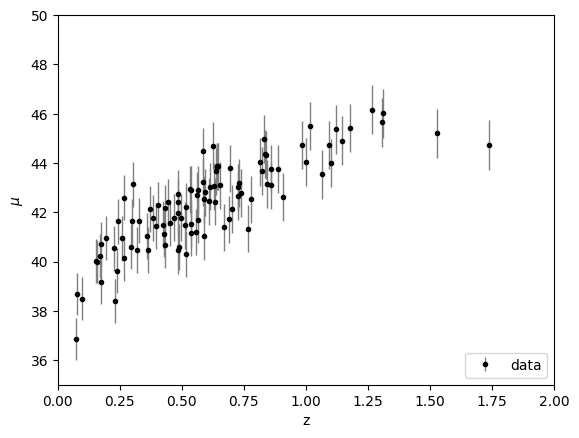

In [16]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla
  
x1,y, dy2 = zip(*sorted(zip(z_sample, mu_sample,dmu)))
x1= np.array(x1)
x=x1[:,np.newaxis]

kernel2 = kernels.RBF(1/0.5, (1/0.5, 1/0.5))
gp2 = GaussianProcessRegressor(kernel=kernel2,
                               alpha=np.array(dy2) ** 2, 
                               random_state=0,optimizer=None)
gp2.fit(x, y)
f2, f2_err = gp2.predict(x,
                        return_std=True) 


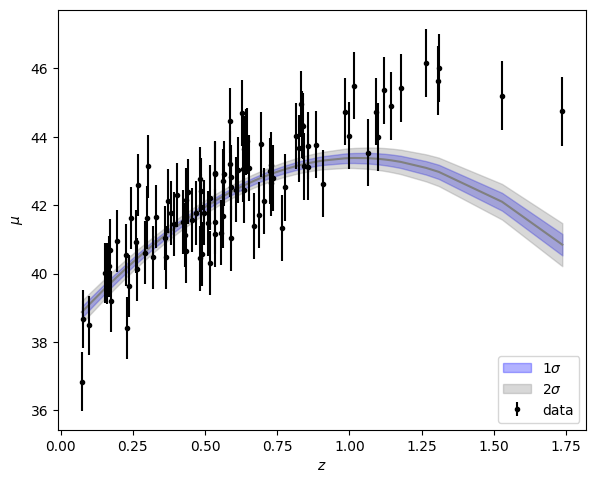

In [55]:
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(223)
ax.plot(x1, f2, '-', color='gray')
ax.fill_between(x1, f2 - f2_err, f2 + f2_err, 
                color='blue', alpha=0.3, label='1$\sigma$')
ax.errorbar(x1, y, dy2, fmt='.k', ms=6, label='data')
ax.fill_between(x1, f2 - 2 * f2_err, f2 + 2 * f2_err, 
                color='gray', alpha=0.3, label='2$\sigma$')

ax.set_xlabel('$z$')
ax.set_ylabel('$\mu$')
plt.legend(loc='lower right')
plt.show()


Now generation of new data using Inverse trasform sampling 

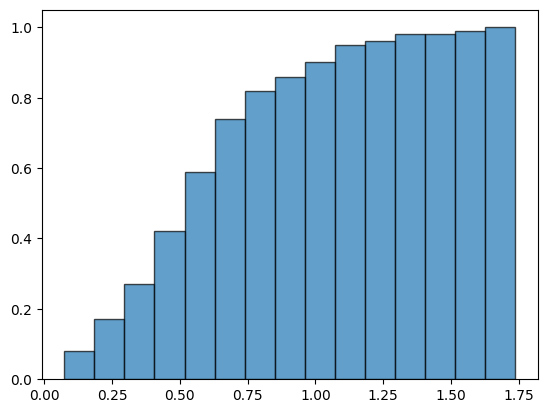

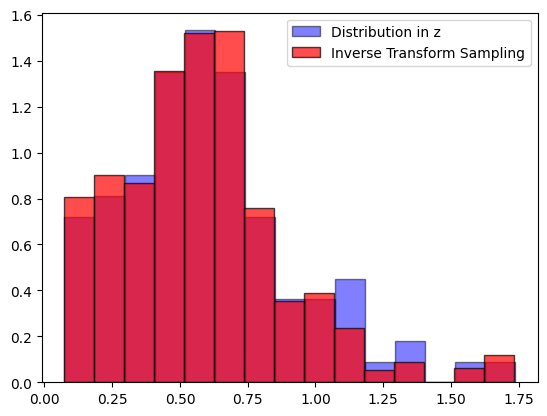

In [82]:
a,b,c=plt.hist(x1,15, edgecolor='black', cumulative=True, alpha=0.7, density=True) # a values of cumulative 
plt.show()
y=np.random.uniform(0,1,1000)

index=np.searchsorted(a,y) #where y would be inserted in a

z_new=np.random.uniform(b[index], b[index+1])

plt.hist(x1, bins=15, edgecolor='black', color='blue', density=True, alpha=0.5, label='Distribution in z' )
plt.hist(z_new, bins=15, edgecolor='black', color='red', density=True, alpha=0.7, label='Inverse Transform Sampling')
plt.legend()
plt.show()



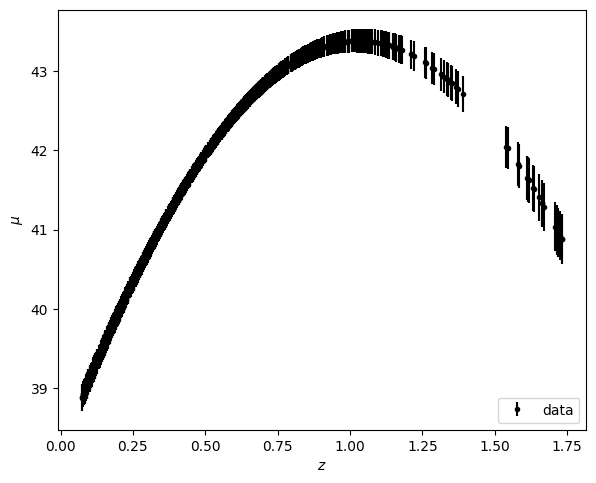

In [83]:
n1, n1_err = gp2.predict(z_new[:,np.newaxis],
                        return_std=True) 

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(223)
#ax.plot(z_new, n1, '-', color='gray')
#ax.fill_between(z_new, n1 - n1_err, n1 + n1_err, color='blue', alpha=0.3, label='1$\sigma$')
ax.errorbar(z_new, n1, n1_err, fmt='.k', ms=6, label='data')
#ax.fill_between(z_new, n1 - 2 * n1_err, n1 + 2 * n1_err,  color='gray', alpha=0.3, label='2$\sigma$')

ax.set_xlabel('$z$')
ax.set_ylabel('$\mu$')
plt.legend(loc='lower right')
plt.show()